# Explore Data

Load an experimental dataset using the same path convention as the other notebooks, then inspect target-label distributions with one histogram per label.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from project_config.variables import address_dict

cwd = Path.cwd().resolve()
repo_root = next(
    (candidate for candidate in [cwd, *cwd.parents] if (candidate / 'project_config').exists()),
    cwd,
)
repo_root


PosixPath('/Users/charmainechia/Documents/projects/AbCode')

In [8]:
from pathlib import Path

from project_config.variables import address_dict

cwd = Path.cwd().resolve()
repo_root = next(
    (candidate for candidate in [cwd, *cwd.parents] if (candidate / 'project_config').exists()),
    cwd,
)

user_inputs = {}

# Edit these for your run.
user_inputs['root_key'] = 'biostream-developability-data' # 'examples' #
user_inputs['data_fbase'] = user_inputs['root_key']
user_inputs['data_subfolder'] = 'tubespin' # 'opensource' #
user_inputs['dataset_suffix'] = '_long' # '' #
default_dataset_fname = user_inputs['data_subfolder'] + user_inputs['dataset_suffix']  + '.csv'
user_inputs['dataset_fname'] = default_dataset_fname

expdata_dir = (repo_root / Path(address_dict[user_inputs['root_key']]) / 'expdata' / user_inputs['data_subfolder']).resolve()
csv_path = expdata_dir / user_inputs['dataset_fname']

# Adjust per-target histogram bins here.
default_bins = 30
bins_by_target = {
    'hic_rt_avg': 80,
    'sec_%monomer_avg': 80,
    'acsins_dLmax_ph7.4_avg': 80,
    'tm1_nanodsf_avg': 80,
}
bins_by_target = {
    'HCCF_HMW': 10,
    'HCCF_Monomer': 10,
    'ProA_HMW': 10,
    'ProA_Monomer': 10,
    'AC-SINS': 10,
}
target_cols = list(bins_by_target.keys())

print(f'Loading dataset from: {csv_path}')
df = pd.read_csv(csv_path)
print(f'Dataset shape: {df.shape}')
display(df.head())


Loading dataset from: /Users/charmainechia/Documents/projects/biostream-developability-data/expdata/tubespin/tubespin_long.csv
Dataset shape: (128, 36)


,Batch,Samples,Media,HCCF_HMW,ProA_HMW,HCCF_Monomer,ProA_Monomer,HCCF_LMW,ProA_LMW,AC-SINS,...,CD3 VH_HCK,G4S Linker2_HCK,CD3 VL_HCK,HCK,Overall_HeavyChainKnob,CD20-VH-CH1_HCH,HCH,Overall_HCH,CD20-VL-CL_LC1,CD20-VL-CL_LC1.1
0,1,CD3A,Excell,27.50,17.20,51.95,80.14,20.55,2.65,11.5,...,EVQLVESGGGLVQPGGSLKLSCAASGFTFNKYAMNWVRQAPGKGLE...,GGGGSGGGGSGGGGS,QTVVTQEPSLTVSPGGTVTLTCGSSTGAVTSGNYPNWVQQKPGQAP...,LEGGGGDKTHTCPPCPAPEAAGGPSVFLFPPKPKDTLMISRTPEVT...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,KTHTCPPCPAPEAAGGPSVFLFPPKPKDTLMISRTPEVTCVVVDVS...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,DIVMTQTPLSLPVTPGEPASISCRSSKSLLHSNGITYLYWYLQKPG...,DIVMTQTPLSLPVTPGEPASISCRSSKSLLHSNGITYLYWYLQKPG...
1,1,H36L1,Excell,35.09,17.40,43.67,78.67,21.25,3.93,10.1,...,EVQLLESGGGVVRPGGSLRLSCAASGFTFNTYAMNWVRQAPGKGLE...,GGGGSGGGGSGGGGS,QSVLTQPPSVSVSPGQTASITCRSSTGAVTTSNYANWVQQKSGQAP...,LEGGGGDKTHTCPPCPAPEAAGGPSVFLFPPKPKDTLMISRTPEVT...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,KTHTCPPCPAPEAAGGPSVFLFPPKPKDTLMISRTPEVTCVVVDVS...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,DIVMTQTPLSLPVTPGEPASISCRSSKSLLHSNGITYLYWYLQKPG...,DIVMTQTPLSLPVTPGEPASISCRSSKSLLHSNGITYLYWYLQKPG...
2,1,H36L2,Excell,32.54,13.79,47.38,83.75,20.08,2.47,8.2,...,EVQLLESGGGVVRPGGSLRLSCAASGFTFNTYAMNWVRQAPGKGLE...,GGGGSGGGGSGGGGS,QSVLTQPPSASASLGASVTLTCRSSTGAVTTSNYANWVQQKSGQAP...,LEGGGGDKTHTCPPCPAPEAAGGPSVFLFPPKPKDTLMISRTPEVT...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,KTHTCPPCPAPEAAGGPSVFLFPPKPKDTLMISRTPEVTCVVVDVS...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,DIVMTQTPLSLPVTPGEPASISCRSSKSLLHSNGITYLYWYLQKPG...,DIVMTQTPLSLPVTPGEPASISCRSSKSLLHSNGITYLYWYLQKPG...
3,1,H36L4,Excell,29.45,12.12,49.99,87.21,20.56,0.68,10.6,...,EVQLLESGGGVVRPGGSLRLSCAASGFTFNTYAMNWVRQAPGKGLE...,GGGGSGGGGSGGGGS,QTVVTQDPAVSVALGQTVRITCRSSTGAVTTSNYANWVQQLPGKAP...,LEGGGGDKTHTCPPCPAPEAAGGPSVFLFPPKPKDTLMISRTPEVT...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,KTHTCPPCPAPEAAGGPSVFLFPPKPKDTLMISRTPEVTCVVVDVS...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,DIVMTQTPLSLPVTPGEPASISCRSSKSLLHSNGITYLYWYLQKPG...,DIVMTQTPLSLPVTPGEPASISCRSSKSLLHSNGITYLYWYLQKPG...
4,1,H36L5,Excell,33.72,16.51,44.03,80.51,22.26,2.98,8.1,...,EVQLLESGGGVVRPGGSLRLSCAASGFTFNTYAMNWVRQAPGKGLE...,GGGGSGGGGSGGGGS,QSALTQEPSLTVSPGGTVTLTCRSSTGAVTTSNYANWVQQTPGTAP...,LEGGGGDKTHTCPPCPAPEAAGGPSVFLFPPKPKDTLMISRTPEVT...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,KTHTCPPCPAPEAAGGPSVFLFPPKPKDTLMISRTPEVTCVVVDVS...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,DIVMTQTPLSLPVTPGEPASISCRSSKSLLHSNGITYLYWYLQKPG...,DIVMTQTPLSLPVTPGEPASISCRSSKSLLHSNGITYLYWYLQKPG...


,non_null_count
HCCF_HMW,128
HCCF_Monomer,128
ProA_HMW,128
ProA_Monomer,128
AC-SINS,128


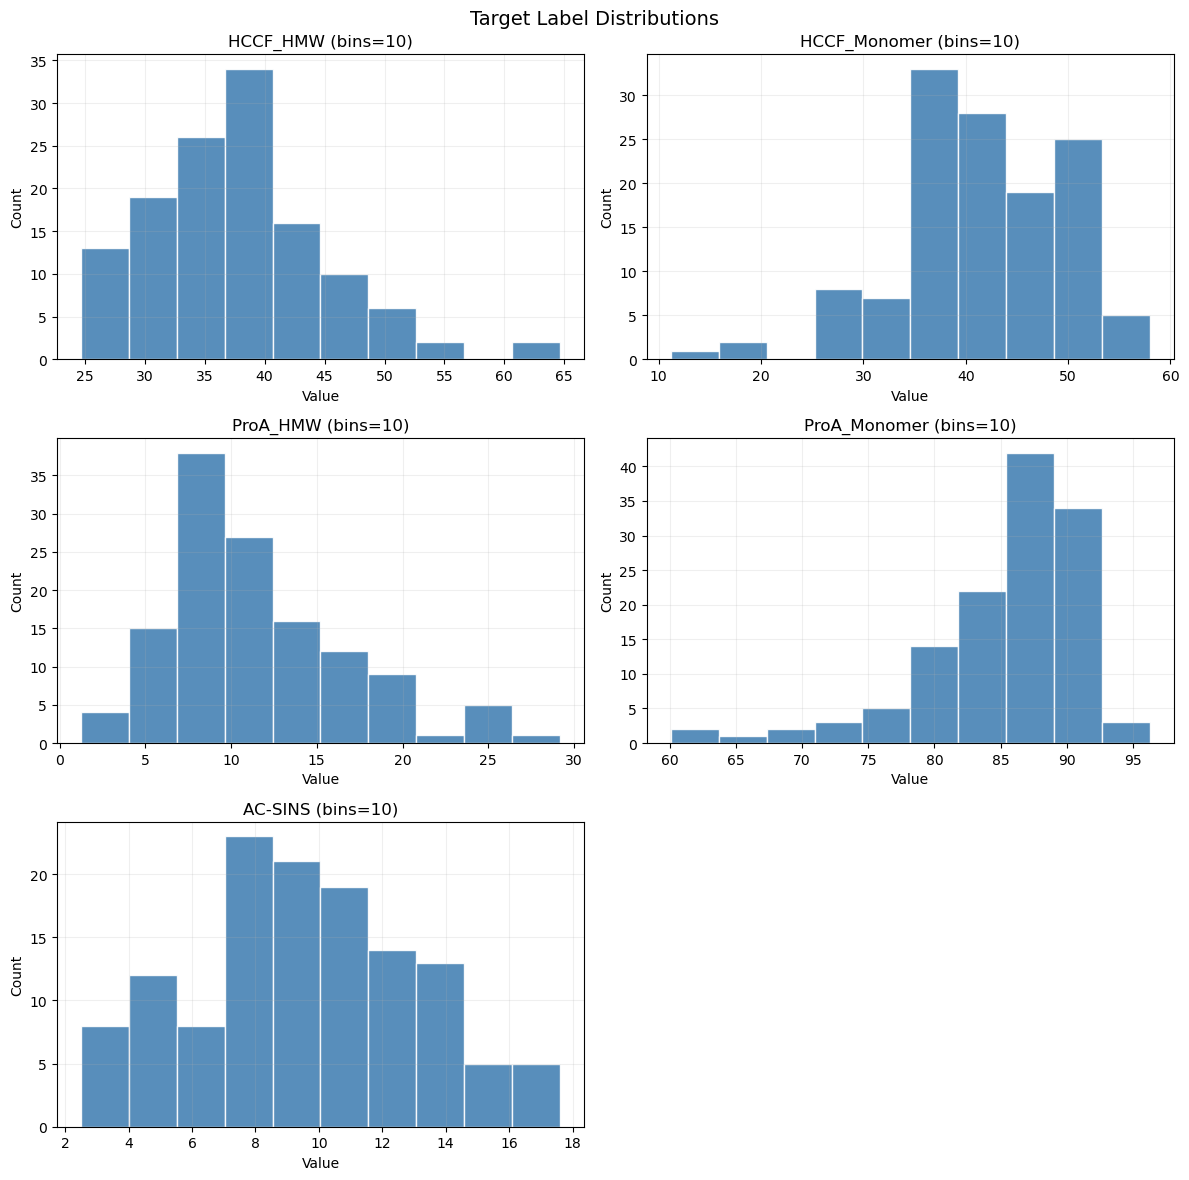

In [9]:
missing_cols = [col for col in target_cols if col not in df.columns]
if missing_cols:
    raise KeyError(f'Missing target columns in dataset: {missing_cols}')

plot_df = df[target_cols].apply(pd.to_numeric, errors='coerce')
valid_counts = plot_df.notna().sum().sort_values(ascending=False)
display(valid_counts.rename('non_null_count').to_frame())

n_targets = len(target_cols)
ncols = 2
nrows = (n_targets + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, target_cols):
    series = plot_df[col].dropna()
    bins = bins_by_target.get(col, default_bins)
    ax.hist(series, bins=bins, color='steelblue', edgecolor='white', alpha=0.9)
    ax.set_title(f'{col} (bins={bins})')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.grid(alpha=0.2)

for ax in axes_flat[n_targets:]:
    ax.set_visible(False)

fig.suptitle('Target Label Distributions', fontsize=14)
fig.tight_layout()
plt.show()
